In [ ]:
#!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

In [ ]:
!pip install textblob

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
# Load data
path = r"C:\mindful-ai\sapient-ds\2025\reference\day-04\regression-exercise\airbnb-newyork\AB_NYC_2019.csv"
df = pd.read_csv(path, low_memory=False)
print("Loaded:", df.shape)
print("Columns:", df.columns.tolist())


Loaded: (48895, 16)
Columns: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [5]:
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


In [6]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 3. Basic Cleaning
- Remove listings with missing price or zero price
- Remove extreme prices (> $1000) for stability


In [7]:
df = df[df['price'] > 0]
df = df[df['price'] <= 1000]
df.reset_index(drop=True, inplace=True)

print("After filtering:", df.shape)


After filtering: (48645, 16)


## 4. Text Feature Engineering
We will use the `name` column as text input:
- Length of name
- Word count
- Presence of certain keywords
- Sentiment score
- TF-IDF vectorization


In [8]:
import re
from textblob import TextBlob

In [9]:
def safe_text(x):
    return '' if pd.isna(x) else str(x)

In [10]:
df['name_text'] = df['name'].apply(safe_text)
df['name_len'] = df['name_text'].apply(len)
df['name_words'] = df['name_text'].apply(lambda s: len(s.split()))

In [11]:
keywords = ['cozy', 'luxury', 'spacious', 'modern', 'private', 'view']
for kw in keywords:
    df[f'kw_{kw}'] = df['name_text'].str.lower().str.contains(kw).fillna(False).astype(int)

In [12]:
df['name_sentiment'] = df['name_text'].apply(lambda s: TextBlob(s).sentiment.polarity if s else 0)


In [13]:
df[['name_text','name_len','name_words','name_sentiment']].head()

,name_text,name_len,name_words,name_sentiment
0,Clean & quiet apt home by the park,34,8,0.322222
1,Skylit Midtown Castle,21,3,0.000000
2,THE VILLAGE OF HARLEM....NEW YORK !,35,6,0.000000
3,Cozy Entire Floor of Brownstone,31,5,-0.100000
4,Entire Apt: Spacious Studio/Loft by central park,48,7,0.200000


## 5. Feature Selection
We'll keep:
- Numeric: latitude, longitude, minimum_nights, number_of_reviews, reviews_per_month, availability_365
- Categorical: neighbourhood_group, room_type
- Text: name

In [14]:
num_cols = ['latitude','longitude','minimum_nights','number_of_reviews','reviews_per_month','availability_365']
cat_cols = ['neighbourhood_group','room_type']
text_col = 'name_text'

## 6. Train/Test Split
We use log(price) as the target to reduce skew.

In [15]:
from sklearn.model_selection import train_test_split
import numpy as np

X = df[num_cols + cat_cols + [text_col]]
y = np.log1p(df['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 7. Preprocessing Pipelines
Separate numeric, categorical, and text transformations.

The main goals of preprocessing are:

Handle missing values

Transform features into model-friendly formats

Ensure consistent scaling and encoding

Reduce dimensionality when dealing with high-dimensional text## 0. Understanding the Preprocessing Stages

Before we train any model, we must prepare our dataset so that it is:
- Free of missing values
- All features are in numeric form
- Scaled appropriately (for models that need it)
- Reduced in dimensionality when working with high-dimensional data (like text)

We build **three pipelines**:
1. **Numeric Pipeline** — Median imputation and scaling
2. **Categorical Pipeline** — Constant imputation and One-Hot Encoding
3. **Text Pipeline** — TF-IDF vectorization + Truncated SVD

Finally, we combine them with a `ColumnTransformer` so they run in parallel.

The goal:
- **Numeric** → handle missing, scale for algorithms like Ridge  
- **Categorical** → convert text labels into binary dummy columns  
- **Text** → convert long text into structured numeric form while keeping the most useful components  


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [17]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

text_pipeline_ridge = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=2000, stop_words='english')),
    ('svd', TruncatedSVD(n_components=50, random_state=42))
])

text_pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, stop_words='english')),
    ('svd', TruncatedSVD(n_components=20, random_state=42))
])

preprocessor_ridge = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols),
    ('text', text_pipeline_ridge, text_col)
])

preprocessor_rf = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols),
    ('text', text_pipeline_rf, text_col)
])

## 8. Ridge Regression Model

In [18]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pipe_ridge = Pipeline([
    ('pre', preprocessor_ridge),
    ('model', Ridge(alpha=1.0))
])

pipe_ridge.fit(X_train, y_train)
y_pred_ridge = np.expm1(pipe_ridge.predict(X_test))

print("Ridge Regression Performance:")
print("RMSE:", mean_squared_error(np.expm1(y_test), y_pred_ridge, squared=False))
print("MAE:", mean_absolute_error(np.expm1(y_test), y_pred_ridge))
print("R²:", r2_score(np.expm1(y_test), y_pred_ridge))


Ridge Regression Performance:
RMSE: 94.04194486448054
MAE: 49.56074968947173
R²: 0.36614372724055233


c:\Users\mindf\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 9. Random Forest Regression Model


In [19]:
from sklearn.ensemble import RandomForestRegressor

pipe_rf = Pipeline([
    ('pre', preprocessor_rf),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = np.expm1(pipe_rf.predict(X_test))

print("Random Forest Performance:")
print("RMSE:", mean_squared_error(np.expm1(y_test), y_pred_rf, squared=False))
print("MAE:", mean_absolute_error(np.expm1(y_test), y_pred_rf))
print("R²:", r2_score(np.expm1(y_test), y_pred_rf))


Random Forest Performance:
RMSE: 85.98663666181206
MAE: 44.61029431321607
R²: 0.47008097425444795


c:\Users\mindf\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 10. Model Comparison

In [20]:
results = pd.DataFrame({
    'Model': ['Ridge Regression', 'Random Forest'],
    'RMSE': [
        mean_squared_error(np.expm1(y_test), y_pred_ridge, squared=False),
        mean_squared_error(np.expm1(y_test), y_pred_rf, squared=False)
    ],
    'MAE': [
        mean_absolute_error(np.expm1(y_test), y_pred_ridge),
        mean_absolute_error(np.expm1(y_test), y_pred_rf)
    ],
    'R²': [
        r2_score(np.expm1(y_test), y_pred_ridge),
        r2_score(np.expm1(y_test), y_pred_rf)
    ]
})
results


c:\Users\mindf\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\mindf\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,Model,RMSE,MAE,R²
0,Ridge Regression,94.041945,49.560750,0.366144
1,Random Forest,85.986637,44.610294,0.470081


## 12. Hyperparameter Tuning
We will tune:
- Ridge Regression: `alpha`
- Random Forest: `n_estimators`, `max_depth`


In [21]:
from sklearn.model_selection import GridSearchCV

# Ridge Regression Grid Search
ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}
ridge_gs = GridSearchCV(
    Pipeline([('pre', preprocessor_ridge), ('model', Ridge())]),
    ridge_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1
)
ridge_gs.fit(X_train, y_train)
print("Best Ridge Params:", ridge_gs.best_params_)
print("Best Ridge RMSE:", -ridge_gs.best_score_)

# Random Forest Grid Search (small grid for speed)
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20]
}
rf_gs = GridSearchCV(
    Pipeline([('pre', preprocessor_rf), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))]),
    rf_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1
)
rf_gs.fit(X_train, y_train)
print("Best RF Params:", rf_gs.best_params_)
print("Best RF RMSE:", -rf_gs.best_score_)


Best Ridge Params: {'model__alpha': 1.0}
Best Ridge RMSE: 0.4366456486767049
Best RF Params: {'model__max_depth': 20, 'model__n_estimators': 200}
Best RF RMSE: 0.3977571006080011


## 13. Model Explainability (Random Forest)
We'll use:
- **Permutation Importance** for global feature importance
- **SHAP values** for local interpretability

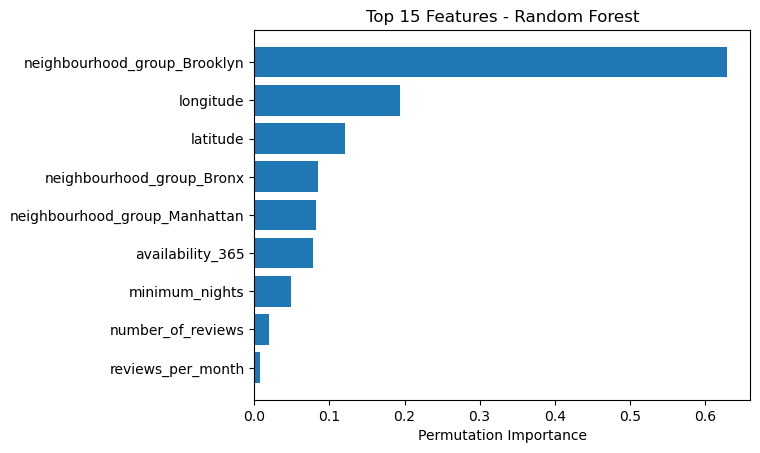

In [22]:
from sklearn.inspection import permutation_importance

# Train final Random Forest with best params
best_rf = rf_gs.best_estimator_
result = permutation_importance(best_rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

import numpy as np
import matplotlib.pyplot as plt

# Extract feature names after preprocessing
cat_feature_names = rf_gs.best_estimator_['pre'].named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols)
feature_names = num_cols + list(cat_feature_names) + [f"svd_{i}" for i in range(20)]

sorted_idx = result.importances_mean.argsort()[-15:]
plt.barh(np.array(feature_names)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Top 15 Features - Random Forest")
plt.show()


### 14. SHAP (Local Interpretability)
SHAP explains individual predictions by showing how each feature pushes the prediction higher or lower.



#### Understanding SHAP and the Necessity of Model Explainability

**SHAP (SHapley Additive exPlanations)** assigns each feature a value showing how much it contributed to a prediction.

Why this matters:
- **Transparency**: We see *why* the model made a certain prediction.
- **Trust**: Stakeholders are more confident in the model.
- **Debugging**: We can catch when the model is using unintended signals.
- **Compliance**: In regulated industries, explainability is not optional.

SHAP is based on Shapley values from cooperative game theory, where each feature is a "player" in predicting the outcome.


In [ ]:
!pip install shap

In [ ]:
# This can take a lot of time!!!

import shap

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(best_rf['model'])
X_test_transformed = best_rf['pre'].transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot (requires feature names from preprocessing)
shap.summary_plot(shap_values, features=X_test_transformed, feature_names=feature_names)


SHAP on the full test set can be slow because:

Random Forests with hundreds of trees generate many calculations per sample.

SHAP’s exact method for trees can be heavy when the dataset is large.

You can speed this up by:

Sampling fewer rows from the test set.

Using permutation importance or shap.Explainer with approximate=True for a rougher (but much faster) estimate.

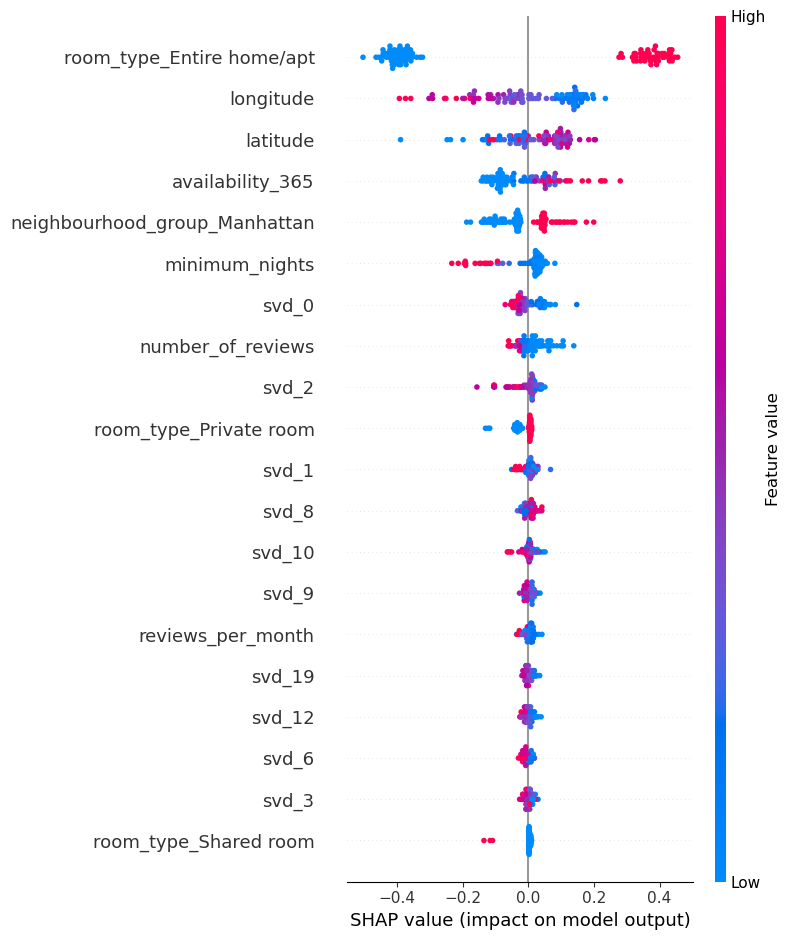

In [23]:
import shap
import numpy as np

# Sample only 100 rows for speed
sample_idx = np.random.choice(len(X_test), 100, replace=False)
X_test_sample = X_test.iloc[sample_idx]

# Use TreeExplainer with the sample
explainer = shap.TreeExplainer(best_rf['model'])
X_test_sample_transformed = best_rf['pre'].transform(X_test_sample)

# Compute SHAP values for only the sample
shap_values_sample = explainer.shap_values(X_test_sample_transformed)

# Summary plot for the sample
shap.summary_plot(shap_values_sample, 
                  features=X_test_sample_transformed, 
                  feature_names=feature_names)


## 15. Final Notes
- Linear models + text features can work surprisingly well, especially with TF-IDF + dimensionality reduction.
- Random Forests often outperform linear models on tabular + text-derived features but are harder to interpret.
- Always balance performance with explainability — stakeholders may need to understand *why* a model predicts certain prices.
- Hyperparameter tuning can make a big difference, but be mindful of overfitting and computation time.


## 16. Making a Sample Prediction

Let's create a fake Airbnb listing and use our trained Random Forest to predict its price.


In [29]:
# Sample new listing
sample_data = pd.DataFrame([{
    'name': 'Cozy apartment near Central Park',
    'host_id': 999999,
    'host_name': 'John Doe',
    'neighbourhood_group': 'Manhattan',
    'neighbourhood': 'Upper West Side',
    'latitude': 40.785091,
    'longitude': -73.968285,
    'room_type': 'Entire home/apt',
    'minimum_nights': 3,
    'number_of_reviews': 15,
    'last_review': '2023-05-10',
    'reviews_per_month': 1.2,
    'calculated_host_listings_count': 1,
    'availability_365': 180
}])

# Reindex to match training columns
sample_data = sample_data.reindex(columns=X.columns, fill_value='')

# Predict
predicted_price = best_rf.predict(sample_data)[0]
print(f"Predicted Price: ${predicted_price:.2f}")


Predicted Price: $5.72


If you’ve built your model inside a pipeline — like:

best_rf = Pipeline([
    ('pre', preprocessor_rf),
    ('model', RandomForestRegressor(...))
])


— then you do NOT need to manually preprocess inputs during prediction.